# XGBoost: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **XGBoost** in Python.

### Concept Overview
An optimized, regularized Gradient Boosting framework designed for high speed and performance.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
\mathcal{L}^{(t)} = \sum_{i=1}^n l\left(y_i, \hat{y}_i^{(t-1)} + f_t(\mathbf{x}_i)\right) + \gamma T + \frac{1}{2}\lambda \sum_{j=1}^T w_j^2
$$

### Real-World Analogy
**Analogy:** Building a custom golf cart engine that is supercharged and has built-in safety features to prevent crashing (overfitting).

### Worked Example
**Worked Example:** Classifying loan default risk. XGBoost fits regularized trees, utilizing parallel CPU threads, handling missing values automatically, and pruning splits that don't improve gain above a threshold.

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn import metrics
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of loan default risk profiles
from sklearn.datasets import make_classification
np.random.seed(42)
X_raw, y_raw = make_classification(n_samples=600, n_features=4, n_informative=3,
                                  n_redundant=1, n_classes=2, weights=[0.85, 0.15],
                                  class_sep=1.3, random_state=42)
df = pd.DataFrame({
    'FICO': np.round(X_raw[:, 0] * 70 + 680, 0),
    'LTV': np.round(np.clip(X_raw[:, 1] * 0.12 + 0.75, 0.1, 1.2), 2),
    'Inquiries': np.round(np.clip(X_raw[:, 2] * 2 + 1, 0, 10), 0).astype(int),
    'Income': np.round(np.clip(X_raw[:, 3] * 25000 + 75000, 15000, 250000), -2),
    'Defaulted': y_raw
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (600, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   FICO       600 non-null    float64
 1   LTV        600 non-null    float64
 2   Inquiries  600 non-null    int64  
 3   Income     600 non-null    float64
 4   Defaulted  600 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 23.6 KB
              FICO         LTV   Inquiries         Income   Defaulted
count   600.000000  600.000000  600.000000     600.000000  600.000000
mean    717.660000    0.770700    0.405000   52066.166667    0.153333
std     111.916889    0.212539    1.166151   30072.158716    0.360609
min     406.000000    0.110000    0.000000   15000.000000    0.000000
25%     645.750000    0.630000    0.000000   31175.000000    0.000000
50%     730.000000    0.810000    0.000000   44600.000000    0.000000
75%     796.250000    0.920000    0.000000   64425.

## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 FICO         0
LTV          0
Inquiries    0
Income       0
Defaulted    0
dtype: int64
Duplicate count: 0


## 6. Exploratory Data Analysis (EDA)

We visualize the distributions and correlations of features.

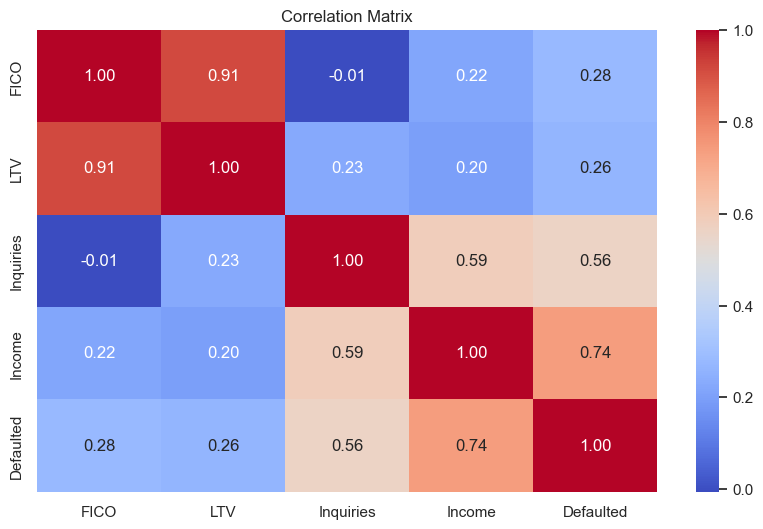

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
print('Scaling not strictly needed for this model.')

Scaling not strictly needed for this model.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (420, 4), Test size: (180, 4)


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
# Build XGBoost Classifier
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                      eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)
print("XGBoost classifier trained.")

XGBoost classifier trained.


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
y_pred = model.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("ROC-AUC:", metrics.roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))

Accuracy: 0.9611111111111111
ROC-AUC: 0.9634478996181124
Confusion Matrix:
 [[138   3]
 [  4  35]]


## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

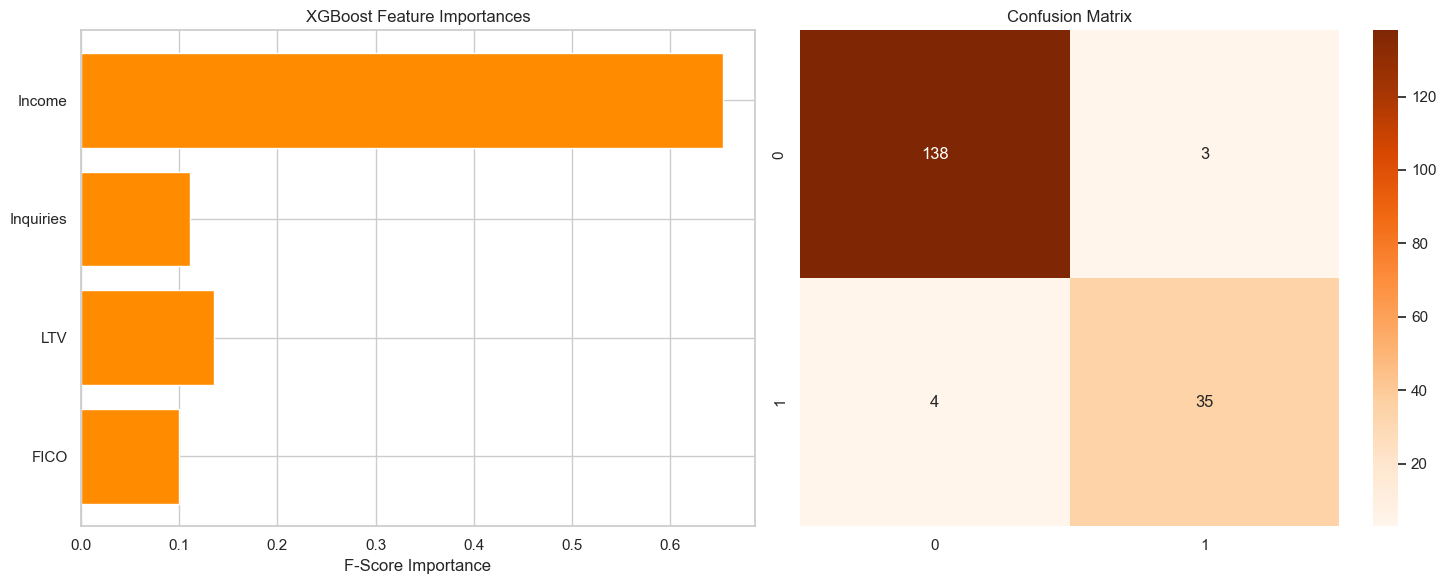

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Plot 1: Feature Importances
importances = model.feature_importances_
axes[0].barh(X.columns, importances, color='darkorange')
axes[0].set_title("XGBoost Feature Importances")
axes[0].set_xlabel("F-Score Importance")

# Plot 2: Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: What makes XGBoost so fast?**

*A: It implements parallel tree building, cache-aware access, block structure data layouts, and a weighted quantile sketch algorithm for fast split candidate selection.*

**Q2: How does XGBoost prevent overfitting?**

*A: By adding L1 (Alpha) and L2 (Lambda) regularization terms directly to the tree objective function loss, and using gamma thresholds to prune splits.*

**Q3: How does XGBoost handle missing values?**

*A: It automatically learns a default direction (left or right split) for missing values based on which direction reduces loss the most during training.*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: What does XGBoost stand for?**

*A: Extreme Gradient Boosting.*

**Q2: Name a key regularization parameter in XGBoost.**

*A: `reg_lambda` (L2 regularization) or `reg_alpha` (L1 regularization).*

**Q3: What is the role of the 'gamma' parameter?**

*A: Specifies the minimum loss reduction required to make a split on a leaf node.*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.